In [1]:
#%pip install spacy
#!python -m spacy download en_core_web_sm
#%pip install transformers

In [2]:
import pandas as pd
import numpy as np
import json
import spacy
import ast
import pickle
from transformers import GPT2Tokenizer, GPT2LMHeadModel
import torch
import os
from collections import defaultdict
from scipy.stats import entropy
from scipy.spatial.distance import jensenshannon
from transformers.utils import logging
logging.set_verbosity_error()  # Suppress warnings from transformers library
import matplotlib.pyplot as plt

%matplotlib inline

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load Dataset

In [3]:
with open("tagged_sentences.pkl","rb") as f:
    tagged_sentences = pickle.load(f)

In [4]:
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

In [5]:
tokenizer = GPT2Tokenizer.from_pretrained('gpt2', device="cuda")
tokenizer.add_special_tokens({'pad_token': '[PAD]'})
# Resize model embeddings to accommodate the new token
model = GPT2LMHeadModel.from_pretrained('gpt2').to("cuda")
model.resize_token_embeddings(len(tokenizer))

Embedding(50258, 768)

In [ ]:
def tag_sentence(text):
    '''
    Retrieve part of speech tags for a sentence of text
    Args:
       text: Input sentence as a string
    Returns:
         List of (word, pos_tag, index) tuples
    '''
    doc = nlp(text)
    return [(token.text, token.pos_, idx) for idx, token in enumerate(doc)]

In [ ]:
def extract_ngrams_from_sentence(sent_idx, ngram_size, tagged_sentence):
    '''
    Extract a list of ngrams from a tagged sentence

      Args:
         sent_idx: Index of the sentence in the corpus
         ngram_size: Size of the ngrams to extract
         tagged_sentence: List of (word, pos_tag) tuples for the sentence
      Returns:
         List of (sent_idx, ngram_position, ngram) tuples
    '''
    results = []
    if len(tagged_sentence) < ngram_size:
       return results
    
    for i in range(len(tagged_sentence) - (ngram_size -1)):
       extracted_ngram = tagged_sentence[i:i+ngram_size]
       results.append((sent_idx, i, extracted_ngram))
    return results

In [ ]:
def get_next_word_pos(sentence, next_word, ngram_position, ngram_size):
  '''
  Get the part of speech tag for the next word in a sentence
      Args:
         sentence: List of (word, pos_tag) tuples for the sentence
         next_word: The next word to get the part of speech tag for
         ngram_position: The position of the ngram in the sentence
         ngram_size: The size of the ngram
      Returns:
          The part of speech tag for the next word
  '''
  sentence_tokens = [word for word, pos in sentence]
  # Create an extended sentence by adding the next word after the current ngram this is to ensure correct tagging with spacy
  extended_sentence = sentence_tokens[:ngram_position+ngram_size] + [next_word]

  tagged = tag_sentence(" ".join(extended_sentence))
  return tagged[-1][1]

In [ ]:
def extract_ngram_ground_truth_pairings(ngram_size, tagged_sentences):
    '''
    Extract ngrams from a list of tagged sentences
      Args:
         ngram_size: Size of the ngrams to extract
         tagged_sentences: List of tagged sentences, where each sentence is a list of (word, pos_tag) tuples
      Returns:
         List of (ngram, next_word) tuples
    '''
    ngram_pairs = []
    for sent_idx, tagged_sentence in enumerate(tagged_sentences):
       if len(tagged_sentence) < ngram_size:
          continue

       for i in range(len(tagged_sentence) - (ngram_size -1)):
          extracted_ngram = tagged_sentence[i:i+ngram_size]
          # Get the next word if it exists after the ngram in the sentence, otherwise None
          next_word = tagged_sentence[i + ngram_size] if (i + ngram_size) < len(tagged_sentence) else None
          ngram_pairs.append((extracted_ngram, next_word))
    return ngram_pairs

In [ ]:
def compute_kl_divergence(real_matrix, generated_matrix, epsilon=1e-10):
   '''
   Compute KL divergence between two matrices
      Args:
         real_matrix: DataFrame containing real probabilities
         generated_matrix: DataFrame containing generated probabilities
         epsilon: Small value to avoid log(0)
      Returns:
         Dictionary mapping ngrams to their KL divergence scores
   '''
   kl_scores = {}

   for ngram in real_matrix.index:
      if ngram in generated_matrix.index:
         real_probs = real_matrix.loc[ngram].values
         gen_probs = generated_matrix.loc[ngram].values

         real_sum = real_probs.sum()
         gen_sum = gen_probs.sum()

         if real_sum == 0 or gen_sum == 0:
            kl_scores[ngram] = 0.0
            continue

         real_probs = real_probs / real_sum
         gen_probs = gen_probs / gen_sum

         gen_probs = np.clip(gen_probs, epsilon, 1)

         kl_scores[ngram] = entropy(real_probs, gen_probs)
   return kl_scores

In [ ]:
def compute_js_divergence(real_matrix, generated_matrix, epsilon=1e-10):
    """
    Compute Jensen-Shannon divergence between real and generated POS probability matrices.
    Args:
        real_matrix: DataFrame containing real probabilities
        generated_matrix: DataFrame containing generated probabilities
        epsilon: Small value to avoid log(0)
    Returns:
        Dictionary mapping ngrams to their JS divergence scores
    """
    js_scores = {}

    for ngram in real_matrix.index:
        if ngram in generated_matrix.index:
            real_probs = real_matrix.loc[ngram].values
            gen_probs = generated_matrix.loc[ngram].values

            real_sum = real_probs.sum()
            gen_sum = gen_probs.sum()

            if real_sum == 0 or gen_sum == 0:
              js_scores[ngram] = 0.0
              continue


            real_probs = real_probs / real_sum
            gen_probs = gen_probs / gen_sum

            gen_probs = np.clip(gen_probs, epsilon, 1)

            js_scores[ngram] = jensenshannon(real_probs, gen_probs)

    return js_scores

In [12]:
# Define training and testing sets
train_size = int(len(tagged_sentences)*0.8)
train_sentences = tagged_sentences[:train_size]
test_sentences = tagged_sentences[train_size:]

In [13]:
len(tagged_sentences)

10000

In [97]:
# Define the ngram size
ngram_size = 3

In [98]:
# Extract ngrams from the training set
text_ngrams = []
for ix, tagged_sentence in enumerate(train_sentences):
  text_ngrams.extend(extract_ngrams_from_sentence(ix, ngram_size, tagged_sentence))

In [99]:
# Create a list of strings from the ngrams
# This will be used for the model to generate text
text_segments = []
for ngram in text_ngrams:
    text_segments.append(" ".join([token[0] for token in ngram[2]]))

In [100]:
# Generate the next word for each ngram
# This will be used to create the probability matrix
text_encodings = tokenizer(text_segments, truncation=True, padding=True,return_tensors="pt")
input_ids = text_encodings['input_ids']
attention_mask = text_encodings['attention_mask']
batch_size = 64

generated_outputs = []

for i in range(0, len(input_ids), batch_size):
  batch_input_ids = input_ids[i:i+batch_size].to("cuda")
  batch_attention_mask = attention_mask[i:i+batch_size].to("cuda")

  with torch.no_grad():
      outputs = model.generate(
          input_ids=batch_input_ids,
          attention_mask=batch_attention_mask,
          max_new_tokens=1,
          temperature=0,
          do_sample=False,
          return_dict_in_generate=True,
          output_scores=True,
          pad_token_id=tokenizer.pad_token_id
      )
      generated_outputs.append(outputs.sequences.detach().cpu())
      del outputs
      torch.cuda.empty_cache()

generated_outputs = torch.cat(generated_outputs, dim=0)
next_word_tokens = tokenizer.batch_decode(generated_outputs[:,-1], skip_special_tokens=True)

del batch_input_ids, batch_attention_mask

In [101]:
# Build transition matrices
def dd():
    return defaultdict(int)
transition_frequency_matrix = defaultdict(dd)
gt_transition_frequency_matrix = defaultdict(dd)

In [102]:
# Populate the transition matrix with counts

# Generated next words
for ngram, next_word in zip(text_ngrams, next_word_tokens):
    sent_idx = ngram[0]
    ngram_position = ngram[1]
    sentence = train_sentences[sent_idx]
    next_word_pos = get_next_word_pos(sentence, next_word, ngram_position, ngram_size)
    pos_ngram = "->".join([token[1] for token in ngram[2]])
    # Update the frequency matrix
    transition_frequency_matrix[pos_ngram][next_word_pos] += 1

# Ground truth next words
ngrams_with_next = extract_ngram_ground_truth_pairings(ngram_size, train_sentences)
for ngram, next_word in ngrams_with_next:
  pos_ngram = "->".join([token[1] for token in ngram])
  # if next_word is None, assign 'NONE' as the POS tag
  next_word_pos = next_word[1] if next_word else 'NONE'
  # Update the frequency matrix
  gt_transition_frequency_matrix[pos_ngram][next_word_pos] += 1

# Convert frequency matrices to probability matrices
transition_prob_matrix = defaultdict(dd)
gt_transition_prob_matrix = defaultdict(dd)
for ngram, pos_counts in transition_frequency_matrix.items():
  total = sum(pos_counts.values())
  for pos, count in pos_counts.items():
    transition_prob_matrix[ngram][pos] = count / total

for ngram, pos_counts in gt_transition_frequency_matrix.items():
  total = sum(pos_counts.values())
  for pos, count in pos_counts.items():
      gt_transition_prob_matrix[ngram][pos] = count / total

# Create DataFrames for easier manipulation
transition_df = pd.DataFrame(transition_prob_matrix).transpose().fillna(0)
gt_transition_df = pd.DataFrame(gt_transition_prob_matrix).transpose().fillna(0)

# Ensure both DataFrames have the same columns
gt_transition_df['SPACE'] = 0.0
transition_df['NONE'] = 0.0

In [103]:
columns = sorted(gt_transition_df.columns)
kl_scores = compute_kl_divergence(gt_transition_df[columns], transition_df[columns])
js_scores = compute_js_divergence(gt_transition_df[columns], transition_df[columns])

In [104]:
test_transition_matrix = defaultdict(dd)
test_ngrams_with_next = extract_ngram_ground_truth_pairings(ngram_size, test_sentences)
for ngram, next_word in test_ngrams_with_next:
  pos_ngram = "->".join([token[1] for token in ngram])
  next_word_pos = next_word[1] if next_word else 'NONE'
  test_transition_matrix[pos_ngram][next_word_pos] += 1

for ngram, pos_counts in test_transition_matrix.items():
  total = sum(pos_counts.values())
  for pos, count in pos_counts.items():
      test_transition_matrix[ngram][pos] = count / total

test_transition_df = pd.DataFrame(test_transition_matrix).transpose().fillna(0)
test_transition_df['SPACE'] = 0.0

In [105]:
# Compute transition frequency DataFrames
transition_frequency_df = pd.DataFrame(transition_frequency_matrix).transpose().fillna(0)
gt_transition_frequency_df = pd.DataFrame(gt_transition_frequency_matrix).transpose().fillna(0)
gt_transition_frequency_df['SPACE'] = 0.0
transition_frequency_df['NONE'] = 0.0

In [106]:
js_scores = compute_js_divergence(gt_transition_df[columns], transition_df[columns])
js_values = list(js_scores.values())

/tmp/ipykernel_966/79948941.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


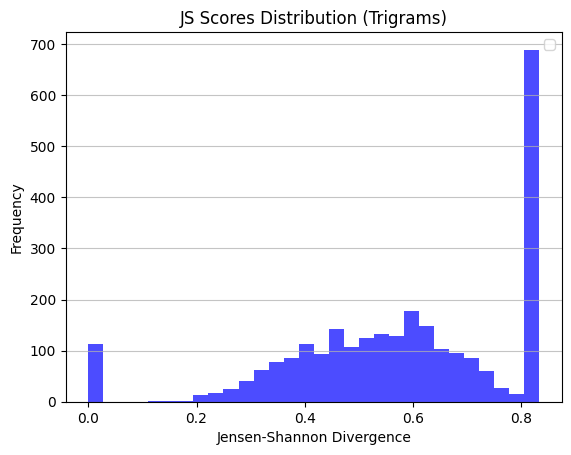

In [107]:
plt.hist(js_values, bins=30, alpha=0.7, color='blue')
plt.title('JS Scores Distribution (Trigrams)')
plt.xlabel('Jensen-Shannon Divergence')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.legend()
plt.show()

In [ ]:
# Compute total transitions per ngram
transitions_per_row = transition_frequency_df.sum(axis=1)
gt_transitions_per_row = gt_transition_frequency_df.sum(axis=1)

In [63]:
transitions_per_row.describe()

count    2680.000000
mean       59.212313
std       198.618925
min         1.000000
25%         2.000000
50%         9.000000
75%        38.000000
max      4059.000000
dtype: float64

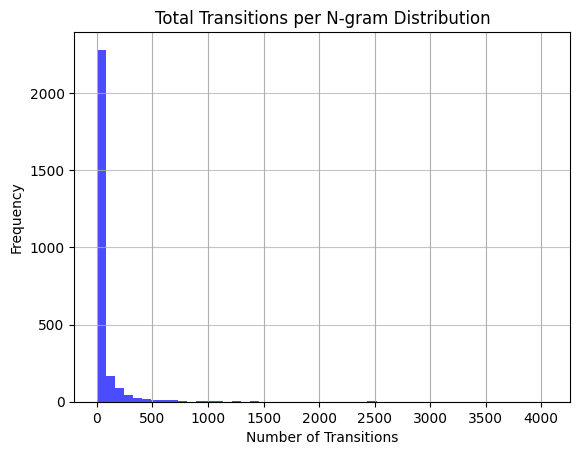

In [65]:
transitions_per_row.hist(bins=50, alpha=0.7, color='blue')
plt.title('Total Transitions per N-gram Distribution')
plt.xlabel('Number of Transitions')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

In [45]:
gt_transitions_per_row.describe()

count    2680.000000
mean       59.212313
std       198.618925
min         1.000000
25%         2.000000
50%         9.000000
75%        38.000000
max      4059.000000
dtype: float64

In [66]:
# Categorize ngrams based on transition counts
low_count_ngrams = transitions_per_row[transitions_per_row < 9].index
middle_count_ngrams = transitions_per_row[(transitions_per_row >= 9) & (transitions_per_row < 38)].index
high_count_ngrams = transitions_per_row[transitions_per_row >= 38].index

In [67]:
# Create separate DataFrames for each category
low_transition_df = transition_df.loc[low_count_ngrams]
middle_transition_df = transition_df.loc[middle_count_ngrams]
high_transition_df = transition_df.loc[high_count_ngrams]
# Create separate DataFrames for each category - ground truth
low_gt_transition_df = gt_transition_df.loc[low_count_ngrams]
middle_gt_transition_df = gt_transition_df.loc[middle_count_ngrams]
high_gt_transition_df = gt_transition_df.loc[high_count_ngrams]

In [68]:
# Compute JS divergence for each category
low_js_scores = compute_js_divergence(low_gt_transition_df[columns], low_transition_df[columns])
middle_js_scores = compute_js_divergence(middle_gt_transition_df[columns], middle_transition_df[columns])
high_js_scores = compute_js_divergence(high_gt_transition_df[columns], high_transition_df[columns])

In [69]:
# Prepare data for plotting
low_js_values = list(low_js_scores.values())
middle_js_values = list(middle_js_scores.values())
high_js_values = list(high_js_scores.values())

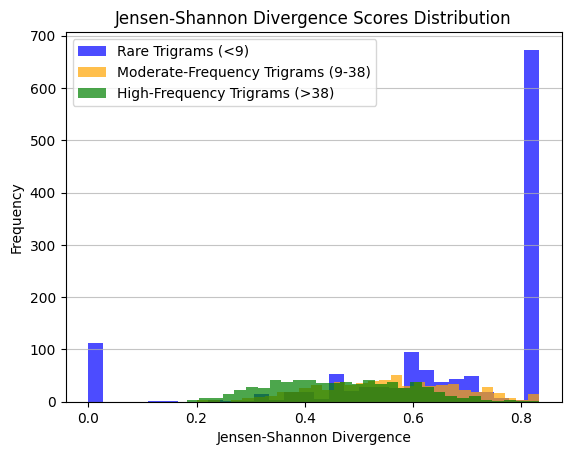

In [71]:
# Plot histograms for each category
plt.hist(low_js_values, bins=30, alpha=0.7, color='blue', label='Rare Trigrams (<9)')
plt.hist(middle_js_values, bins=30, alpha=0.7, color='orange', label='Moderate-Frequency Trigrams (9-38)')
plt.hist(high_js_values, bins=30, alpha=0.7, color='green', label='High-Frequency Trigrams (>38)')
plt.title('Jensen-Shannon Divergence Scores Distribution')
plt.xlabel('Jensen-Shannon Divergence')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.legend()
plt.show()

# Figure: Jensen-Shannon Divergence Scores Distribution for Different N-gram Count Categories

## POS TAG Meanings
* ADJ: Adjective
* ADP: Adposition
* ADV: Adverb
* AUX: Auxiliary
* CONJ: Conjunction
* CCONJ: Coordinating conjunction
* DET: Determiner
* INTJ: Interjection
* NOUN: Noun
* NUM: Numeral
* PART: Particle
* PRON: Pronoun
* PUNCT: Punctuation
* SCONJ: Subordinating conjunction
* SPACE: Space
* SYM: Symbol
* VERB: Verb
* X: Other
* EOL: End of line